---
# <div style="text-align: center"> Introduction </div>
---

Along these tutorials, we will see how <span style="color:blue">**SCOPE**</span> interacts with the different parts of the code to handle the execution of computational workflows. 

These are the topics covered in each tutorial:
1) The **System** class and its sources: the **Specie**, **Cell** and **Atom** classes  
2) The Computational workflow: **Branch**, **Workflow**, **Job**, and **Computation** classes  
3) The **State** class  
4) The **Data**, **Collection** and **VNM** classes
5) The **Input_data** class, and **scope input files**
6) Running <span style="color:blue">**SCOPE**</span> - Part 1: File Structure
7) Running <span style="color:blue">**SCOPE**</span> - Part 2: Execution 
8) Running <span style="color:blue">**SCOPE**</span> - Part 3: Detailed Actions

---
# <div style="text-align: center"> Tutorial 3: The State class</div>
---

In this tutorial, we will discuss the **State** class. A **State** is a 'picture' of a given **Source** during the execution of the computational Workflow. The main purpose of a **State** is to store the initial data for **Computations**, which have the ability to create a new state upon completion, or to update an existing one, depending on the user choices. 

Below, we will discuss how the **State** function works exactly, and how it connects **Species** (and **Cells**) with the computational workflow.  

In [1]:
import os
import scope

In [2]:
## Path of the data folder. It should be "os.path.abspath('.')+'/Data"
data_folder = os.path.abspath('../')+'/Data/1-Tutorial_1/'
## Loads the System object from a binary file, provided in the tutorial folder
sys = scope.load_binary(f"{data_folder}ABITEM.npy")

In [3]:
## All objects in SCOPE have a __repr__ method, so printing shows a summary of the object
print(sys)

-------------------------------------
-- >>> SCOPE System_sco Object >>> --
-------------------------------------
 Version               = 1.0
 Type                  = system
 Subtype               = sco_system
 Source Path           = /data/ucsscms/svela/4-Merged/ABITEM/
 System File Path      = /home/svela/SCOPE/Test_V1/2-Systems/ABITEM/
 System File Name      = /home/svela/SCOPE/Test_V1/2-Systems/ABITEM/ABITEM.npy
 Computations Path     = /home/svela/SCOPE/Test_V1/3-Computations/ABITEM/

 Num Sources           = 6
     idx: type, name, formula               
     0: cell, ABITEM01, H104-C92-N24-O4-S8-Fe4 
     1: cell, ABITEM, H104-C92-N24-O4-S8-Fe4 
     2: cell, ref_hs_cell, H104-C92-N24-O4-S8-Fe4 
     3: cell, ref_ls_cell, H104-C92-N24-O4-S8-Fe4 
     4: specie, ref_hs_mol, H18-C20-N6-S2-Fe 
     5: specie, ref_ls_mol, H18-C20-N6-S2-Fe 

 Num Branches          = 1
     0: isolated, Num Workflows: 2




In [4]:
## Sources can be selected using the find_source function, and using the source name
found, source = sys.find_source("ref_hs_mol")
print(found)
print(source)

True
-----------------------------------
------ SCOPE MOLECULE Object ------
-----------------------------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule
 Name                  = ref_hs_mol
 Number of Atoms       = 47
 Formula               = H18-C20-N6-S2-Fe
 Charge                = 0
 Spin (alpha - beta)   = 4
 Number of Parents     = 1
 Has Adjacency Matrix  = YES
 Has Bonds             = YES

 Num of Ligands        = 3
   Ligand 0: C-N-S with 3 atoms. Smiles: [N-]=C=S
   Ligand 1: H18-C18-N4 with 40 atoms. Smiles: [H]c1nc(C([H])([H])N(C([H])([H])c2nc([H])c([H])c([H])c2[H])C([H])([H])c2nc([H])c([H])c([H])c2[H])c([H])c([H])c1[H]
   Ligand 2: C-N-S with 3 atoms. Smiles: [N-]=C=S

 Num of Metals         = 1
   Metal 0: Fe with charge:2 and spin:4




## States

In [5]:
## Sources have "STATES"
source.states

[---------------------------------------------------
    STATE                                           
 ---------------------------------------------------
  Name                  = initial
  Source Name           = ref_hs_mol
  Source Type           = specie
  Labels                = Fe...
  Coord                 = [3.7430176, 3.9944543, 13.5094621]...
  Number of Units (Z)   = 1
  # Molecules:          = 1
  With Formulae:                               
     0: H18-C20-N6-S2-Fe ,
 ---------------------------------------------------
    STATE                                           
 ---------------------------------------------------
  Name                  = pbe_opt
  Source Name           = ref_hs_mol
  Source Type           = specie
  Labels                = Fe...
  Coord                 = [3.738143, 3.85153, 13.537435]...
  Number of Units (Z)   = 1
  # Molecules:          = 1
  With Formulae:                               
     0: H18-C20-N6-S2-Fe ,
 -----------------------

In [6]:
## These are accessible directly from the list
initial_state = source.states[0]
## Or through the find_state function
found, initial_state = source.find_state("initial")
print(found)
print(initial_state)

True
---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = initial
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.7430176, 3.9944543, 13.5094621]...
 Number of Units (Z)   = 1
 # Molecules:          = 1
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 



In [7]:
## Normally, the "initial" state contains the information of the source when initiated.  
print(initial_state)
## Notice that the coordinates, for example, are just the same
print(source.coord[0])
print(initial_state.coord[0])

## Initial_States are not automatically created when adding a source to a system with sys.add_source(), but this will be discussed in Tutorial 5.

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = initial
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.7430176, 3.9944543, 13.5094621]...
 Number of Units (Z)   = 1
 # Molecules:          = 1
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 

[3.7430176, 3.9944543, 13.5094621]
[3.7430176, 3.9944543, 13.5094621]


In [8]:
## Computations take input information from states, and bring new output information to either (i) the same state, or (ii) a new state that is created.
## In this example, a DFT optimization with PBE was performed, and the output was stored in a new state called "pbe_opt":
found, final_state = source.find_state("pbe_opt")
print(final_state)
## Notice that now the coordinates are different.
print(source.coord[0])        ## The original coordinates
print(initial_state.coord[0]) ## The initial state coordinates, with the same geometry
print(final_state.coord[0])   ## The final state coordinates, with the optimized geometry

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = pbe_opt
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.738143, 3.85153, 13.537435]...
 Number of Units (Z)   = 1
 # Molecules:          = 1
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 

[3.7430176, 3.9944543, 13.5094621]
[3.7430176, 3.9944543, 13.5094621]
[3.738143, 3.85153, 13.537435]


In [9]:
# The final_state contains the coordinates of the molecule after undergoing the following computations (see tutorial 1 for more details on computations):
print(final_state.computations)

[---------------------------------------------------
   >>> >>> >>> >>> COMPUTATION                     
---------------------------------------------------
 Source Type           = specie
 Source sub-Type       = molecule
 Branch Name           = isolated
 Workflow Name         = ref_hs_mol
 Job Keyword           = pbe_opt
---------------------------------------------------
 Initial State         = initial
 Final State           = pbe_opt
 Comp software         = g16
 Comp index            = 1
 Comp step             = 1
 Comp run_number       = 1
 Comp inp_path         = /home/svela/SCOPE/Test_V1/3-Computations/ABITEM/isolated/ABITEM_ref_hs_mol_opt_r1.com
 Comp out_path         = /home/svela/SCOPE/Test_V1/3-Computations/ABITEM/isolated/ABITEM_ref_hs_mol_opt_r1.log
 Comp isregistered     = True
 Comp isgood           = True
 Comp isfinished       = True
 Comp elapsed_time     = 54358.6 seconds
 Has OUTPUT            = NO

]


In [10]:
## In this case, only one computation contributed to the final state. Let's take it.
comp = final_state.computations[0]

## Now we'll try to visualize the evolution of the coordinates as a result of this PBE optimization computation.
## Normally, the full output of computations is not stored in the computation-class objects by default. It can be done, but then they become too heavy.
## So we need to re-read the output. Outputs are provided in the Sources Folder, but before, we need to overwrite the path of the computation,.
comp.out_path = f"{data_folder}ABITEM_ref_hs_mol_opt_r1.log" 
## Now we can read it. To do it, we use the create_output() method of the computation class. 
## The OUTPUT class will read the lines of the file. 
output = comp.create_output()

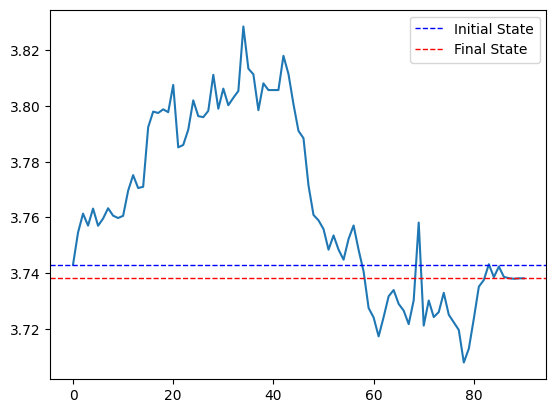

In [11]:
## From the OUTPUT class, we can easily (hopefully) parse the output file

## Here, we extract all geometries.
labels, geoms = output.get_all_geometries()

## This is the evolution of the X coordinate of the first atom along the optimization 
xs = [g[0][0] for g in geoms]

## We plot the evolution of this coordinates, and show that the first step corresponds to the "initial state" coordinates...
## ...and that the last step corresponds to the "final state" 
import matplotlib.pyplot as plt
plt.plot(xs)
plt.axhline(y=initial_state.coord[0][0], color='blue', linestyle='--', linewidth=1, label='Initial State')
plt.axhline(y=final_state.coord[0][0], color='red', linestyle='--', linewidth=1, label='Final State')
plt.legend()
plt.show()

In [12]:
## If multiple computations target the same final state, these keep updating it.

## For instance, when multiple optimization computations are necessary:
   ## Computation 1: Reads initial state (coordinates "A"), optimization runs, and last-step coordinates ("B") are used to create the final state.
   ## Computation 2: Reads set of coordinates "B", continues optimization, and last-step coordinates ("C") update the final state.
   ## ... This goes on until the final coordinates are considered good, or the optimization job stops.

## Why are States necessary?

In [13]:
## For two reasons:

In [14]:
# (1) When a computation finishes, the final information may be different than the that of the source. 
# For instance, a geometry optimization might break a bond, so the initial molecule is no longer the same. 

# Thus, if the user wants to get the molecules out of a STATEs coordinates, they need to be re-computed:
new_molec = final_state.get_moleclist()[0]

## In most cases, the new molecule will have the same chemical composition than the original one (i.e. the source)
original_molec = source

## Notice that Species can be compared based on some compositional criteria (see specie class, function __eq__())
print(original_molec == new_molec)


True


In [15]:
# (2) Because it enables the user to store multiple results of the molecule (e.g. the energy, coordinates).
# for instance, multiple optimization jobs with different DFT functionals:
found, b3lyp_state = source.find_state("b3lyp_opt")
  
print(final_state.results) # REMINDER: above, we defined final_state, as the state that results from a pbe optimization
print(b3lyp_state.results) 

{'energy': energy: -3158.67305783 au}
{'energy': energy: -3159.62579289 au}


In [16]:
# The b3lyp state loaded above contains the information of two computations...
print(len(b3lyp_state.computations))

# Associated with two different jobs, with keywords:
for comp in b3lyp_state.computations:
    print(comp._job.keyword)

2
b3lyp_opt
b3lyp_freq


-----------------------------
   Vibrational Normal Mode   
-----------------------------
 Index                  = 1
 Freq (cm-1)            = 21.6469
 IR Intensity (KM/Mole) = 1.0847
 Reduced Mass (AMU)     = 14.2624
 Has Mode               = False



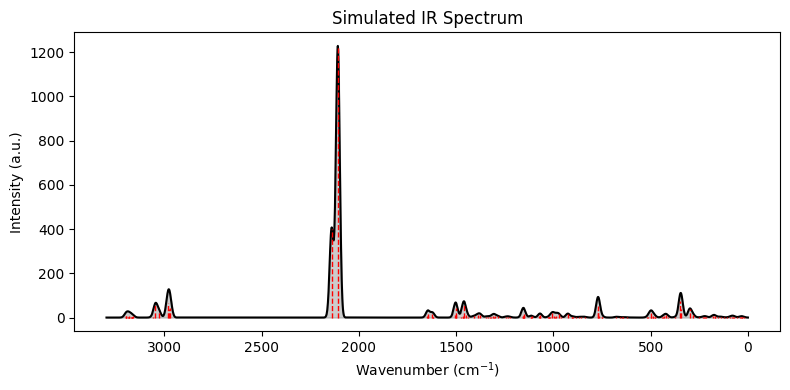

In [17]:
# The second one computes the vibrational normal modes, and stores them:
print(b3lyp_state.VNMs[0])  ## This is the first one

# And this is the resulting IR spectrum
from scope.classes_qc import plot_ir_spectrum
x, spec = plot_ir_spectrum(b3lyp_state.VNMs)

### Help

In [18]:
## Remember, You can always find help in the docstrings: I prepared the most important ones
help(initial_state) 

Help on State in module scope.classes_state object:

class State(builtins.object)
 |  State(_source: object, name: str, debug: int = 0)
 |
 |  Represent a named state associated with a source specie or cell.
 |
 |  A `State` stores geometry-dependent information (coordinates, molecules,
 |  fragmentation status), workflow metadata (computations and results), and
 |  optional vibrational/thermodynamic data.
 |
 |  Methods defined here:
 |
 |  __init__(self, _source: object, name: str, debug: int = 0)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __repr__(self) -> None
 |      Return a human-readable summary of the state.
 |
 |  add_computation(self, computation: object, debug: int = 0)
 |      Add a computation to this state if an equivalent entry is absent.
 |
 |  add_result(self, result: object, overwrite: bool = False)
 |      Attach a result object to the state results dictionary.
 |
 |  check_fragmentation(self, reconstruct: bool = False, debug: int 